In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import glob
from pathlib import Path

import numpy as np
import pandas as pd

from aicsimageio import AICSImage, readers

from tqdm import tqdm

from matplotlib import pyplot as plt
import seaborn as sns

In [46]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['svg.fonttype'] = 'none'

## load layout from file, and plot to check

In [4]:
Experiment1_Layout = pd.read_csv("/Users/alexandergillis/Desktop/publications/2026_POLR2A_homeostasis/Imaging/NikonSpinningDisk/LARP7_7SK/251024_LARP7_7SK/METADATA/251024_LARP7_7SK.csv")
Experiment2_Layout = pd.read_csv("/Users/alexandergillis/Desktop/publications/2026_POLR2A_homeostasis/Imaging/NikonSpinningDisk/LARP7_7SK/251107_LARP7_7SK/METADATA/251107_LARP7_7SK.csv")
Experiment3_Layout = pd.read_csv("/Users/alexandergillis/Desktop/publications/2026_POLR2A_homeostasis/Imaging/NikonSpinningDisk/LARP7_7SK/251117_LARP7_7SK/METADATA/251117_LARP7_7SK.csv")

## load quantification files from relevant directories, and assemble into data frames

In [6]:
quantification_directory_1 = Path("/Users/alexandergillis/Desktop/KATANA_PULL/251024_LARP7_7SK/20251028_182128_239/QUANTIFICATION/")
quantification_directory_2 = Path("/Users/alexandergillis/Desktop/KATANA_PULL/251107_LARP7_7SK/20251111_171722_977/QUANTIFICATION/")
quantification_directory_3 = Path("/Users/alexandergillis/Desktop/KATANA_PULL/251117_LARP7_7SK/20251121_165234_936/QUANTIFICATION/")

quantification_files_1 = glob.glob(str(quantification_directory_1 / "*.csv"))
quantification_files_2 = glob.glob(str(quantification_directory_2 / "*.csv"))
quantification_files_3 = glob.glob(str(quantification_directory_3 / "*.csv"))

len(quantification_files_1), len(quantification_files_2), len(quantification_files_2)

(630, 630, 630)

In [7]:
Path(quantification_files_1[10]).stem, Path(quantification_files_1[10]).stem[4:7],Path(quantification_files_1[10]).stem[40:44]

('WellI07_Channel647,405,None,488_Seq0057_0001.ome', 'I07', '0001')

In [8]:
qdfs = list()


for f in tqdm(quantification_files_1):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_percell_1 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_percell_1['file'].tolist()


wellnames = [f[4:7] for f in files]
quantifcation_percell_1['well'] = wellnames

fovs = [f[40:44] for f in files]
quantifcation_percell_1['fov'] = fovs

100%|████████████████████████████████████████| 630/630 [00:02<00:00, 241.34it/s]


In [9]:
Intensities_Experiment1 = pd.DataFrame({
    "WELL" : quantifcation_percell_1['well'],
    "IF_488_Intensity" : quantifcation_percell_1['Nuclei_intensity_mean_488'],
    "FISH_647_Intensity" : quantifcation_percell_1['Nuclei_intensity_mean_647'],
    "DAPI_Intensity" : quantifcation_percell_1['Nuclei_intensity_mean_405'],
    "NucleusArea" : quantifcation_percell_1['Nuclei_area']
})

In [10]:
qdfs = list()


for f in tqdm(quantification_files_2):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_percell_2 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_percell_2['file'].tolist()


wellnames = [f[4:7] for f in files]
quantifcation_percell_2['well'] = wellnames

fovs = [f[40:44] for f in files]
quantifcation_percell_2['fov'] = fovs

100%|████████████████████████████████████████| 630/630 [00:02<00:00, 304.53it/s]


In [11]:
Intensities_Experiment2 = pd.DataFrame({
    "WELL" : quantifcation_percell_2['well'],
    "IF_488_Intensity" : quantifcation_percell_2['Nuclei_intensity_mean_488'],
    "FISH_647_Intensity" : quantifcation_percell_2['Nuclei_intensity_mean_647'],
    "DAPI_Intensity" : quantifcation_percell_2['Nuclei_intensity_mean_405'],
    "NucleusArea" : quantifcation_percell_2['Nuclei_area']
})

In [18]:
qdfs = list()


for f in tqdm(quantification_files_3):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_percell_3 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_percell_3['file'].tolist()


wellnames = [f[4:7] for f in files]
quantifcation_percell_3['well'] = wellnames

fovs = [f[40:44] for f in files]
quantifcation_percell_3['fov'] = fovs

Intensities_Experiment3 = pd.DataFrame({
    "WELL" : quantifcation_percell_3['well'],
    "IF_488_Intensity" : quantifcation_percell_3['Nuclei_intensity_mean_488'],
    "FISH_647_Intensity" : quantifcation_percell_3['Nuclei_intensity_mean_647'],
    "DAPI_Intensity" : quantifcation_percell_3['Nuclei_intensity_mean_405'],
    "NucleusArea" : quantifcation_percell_3['Nuclei_area']
})

100%|████████████████████████████████████████| 630/630 [00:02<00:00, 268.79it/s]


In [13]:
IntensitiesByWell_Experiment1 = Intensities_Experiment1.groupby('WELL').mean().reset_index().merge(Experiment1_Layout, how = 'left')

In [14]:
CountsByWell_Experiment1 = Intensities_Experiment1.groupby('WELL').count()['NucleusArea'].reset_index()
CountsByWell_Experiment1.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)
IntensitiesByWell_Experiment1 = IntensitiesByWell_Experiment1.merge(CountsByWell_Experiment1, how = 'left')

In [15]:
IntensitiesByWell_Experiment2 = Intensities_Experiment2.groupby('WELL').mean().reset_index().merge(Experiment2_Layout, how = 'left')

In [16]:
CountsByWell_Experiment2 = Intensities_Experiment2.groupby('WELL').count()['NucleusArea'].reset_index()
CountsByWell_Experiment2.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)
IntensitiesByWell_Experiment2 = IntensitiesByWell_Experiment2.merge(CountsByWell_Experiment2, how = 'left')

In [19]:
IntensitiesByWell_Experiment3 = Intensities_Experiment3.groupby('WELL').mean().reset_index().merge(Experiment3_Layout, how = 'left')

In [20]:
CountsByWell_Experiment3 = Intensities_Experiment3.groupby('WELL').count()['NucleusArea'].reset_index()
CountsByWell_Experiment3.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)
IntensitiesByWell_Experiment3 = IntensitiesByWell_Experiment3.merge(CountsByWell_Experiment3, how = 'left')

In [22]:
#e06 excluded, siRNA contamination
IntensitiesByWell_Experiment3 = IntensitiesByWell_Experiment3.query('WELL != "E06"')

## plot raw data of wells as swarm plot

In [23]:
sirna_order = ['OptiMEM only', 
               'Scrambled', 
               'LARP7 pool', 
               'ARMC5 pool', 
               'POLR2B',
               'LARP7 pool + ARMC5', 
               'LARP7 pool + POLR2B']

/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 35.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 40.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 20.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 37.5% of the points cannot be placed; you may want to decrease the size

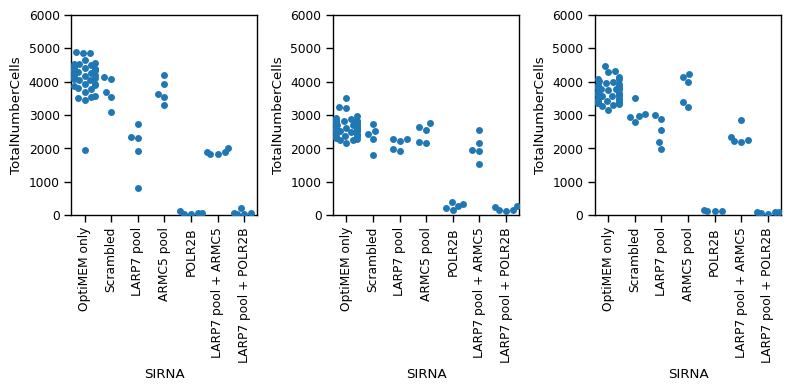

In [24]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 3, figsize = (8,4))

sns.swarmplot(IntensitiesByWell_Experiment1,
              x = 'SIRNA', order = sirna_order,
              y = 'TotalNumberCells',
              ax = a[0])

sns.swarmplot(IntensitiesByWell_Experiment2,
              x = 'SIRNA', order = sirna_order,
              y = 'TotalNumberCells',
              ax = a[1])

sns.swarmplot(IntensitiesByWell_Experiment3,
              x = 'SIRNA', order = sirna_order,
              y = 'TotalNumberCells',
              ax = a[2])

for i in [0,1,2]:
    a[i].set_ylim(0,6000)
    a[i].tick_params(axis = 'x', rotation = 90)

plt.tight_layout()

/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 32.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 7.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 40.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


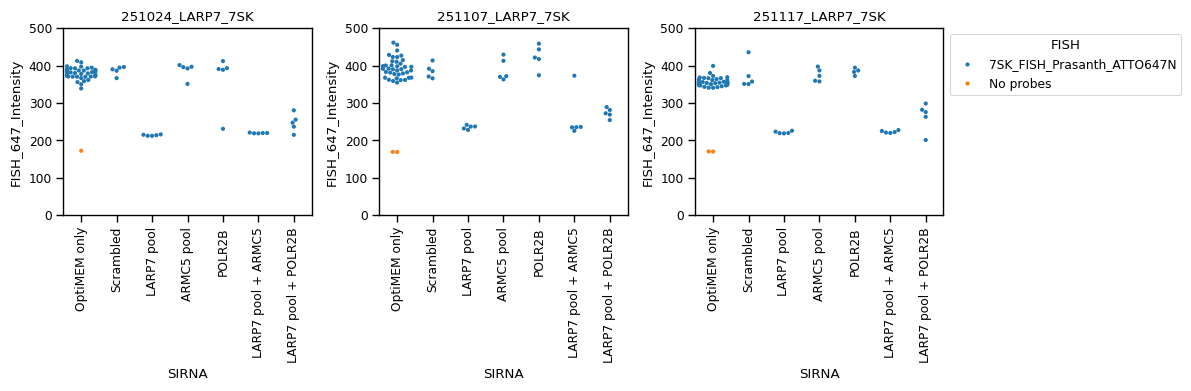

In [25]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 3, figsize = (12,4))

sns.swarmplot(IntensitiesByWell_Experiment1,
              x = 'SIRNA', order = sirna_order,
              y = 'FISH_647_Intensity',
              hue = 'FISH',
              legend = False,
              s = 3,
              ax = a[0])

sns.swarmplot(IntensitiesByWell_Experiment2,
              x = 'SIRNA', order = sirna_order,
              y = 'FISH_647_Intensity',
              hue = 'FISH',
              legend = False,
              s = 3,
              ax = a[1])

g = sns.swarmplot(IntensitiesByWell_Experiment3,
              x = 'SIRNA', order = sirna_order,
              y = 'FISH_647_Intensity',
              hue = 'FISH',
             
              s = 3,
              ax = a[2])

sns.move_legend(g, 'upper left', bbox_to_anchor = (1,1))

for i in [0,1,2]:
    a[i].set_ylim(0,500)
    a[i].tick_params(axis = 'x', rotation = 90)

a[0].set_title('251024_LARP7_7SK')
a[1].set_title('251107_LARP7_7SK')
a[2].set_title('251117_LARP7_7SK')


plt.tight_layout()

/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 10.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


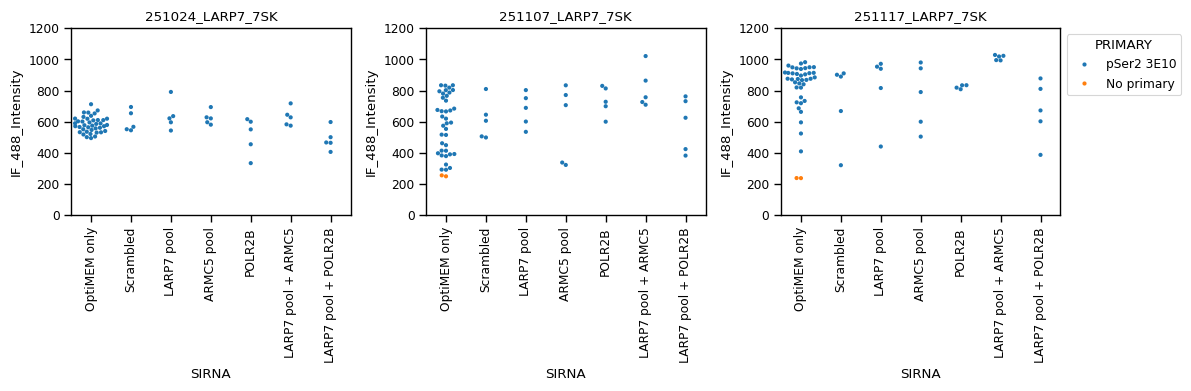

In [26]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 3, figsize = (12,4))

sns.swarmplot(IntensitiesByWell_Experiment1,
              x = 'SIRNA', order = sirna_order,
              y = 'IF_488_Intensity',
              hue = 'PRIMARY',
              legend = False,
              s = 3,
              ax = a[0])

sns.swarmplot(IntensitiesByWell_Experiment2,
              x = 'SIRNA', order = sirna_order,
              y = 'IF_488_Intensity',
              hue = 'PRIMARY',
              legend = False,
              s = 3,
              ax = a[1])

g = sns.swarmplot(IntensitiesByWell_Experiment3,
              x = 'SIRNA', order = sirna_order,
              y = 'IF_488_Intensity',
              hue = 'PRIMARY',
              s = 3,
              ax = a[2])

sns.move_legend(g, 'upper left', bbox_to_anchor = (1,1))

for i in [0,1,2]:
    a[i].set_ylim(0,1200)
    a[i].tick_params(axis = 'x', rotation = 90)

a[0].set_title('251024_LARP7_7SK')
a[1].set_title('251107_LARP7_7SK')
a[2].set_title('251117_LARP7_7SK')

plt.tight_layout()

In [27]:
IntensitiesByWell_Experiment1['ROW'] = [x[:1] for x in IntensitiesByWell_Experiment1['WELL']]
IntensitiesByWell_Experiment1['COLUMN'] = [x[1:] for x in IntensitiesByWell_Experiment1['WELL']]
IntensitiesByWell_Experiment1['COLUMN'] = IntensitiesByWell_Experiment1['COLUMN'].astype(int)

IntensitiesByWell_Experiment2['ROW'] = [x[:1] for x in IntensitiesByWell_Experiment2['WELL']]
IntensitiesByWell_Experiment2['COLUMN'] = [x[1:] for x in IntensitiesByWell_Experiment2['WELL']]
IntensitiesByWell_Experiment2['COLUMN'] = IntensitiesByWell_Experiment2['COLUMN'].astype(int)

IntensitiesByWell_Experiment3['ROW'] = [x[:1] for x in IntensitiesByWell_Experiment3['WELL']]
IntensitiesByWell_Experiment3['COLUMN'] = [x[1:] for x in IntensitiesByWell_Experiment3['WELL']]
IntensitiesByWell_Experiment3['COLUMN'] = IntensitiesByWell_Experiment3['COLUMN'].astype(int)

/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 5.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 25.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 15.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


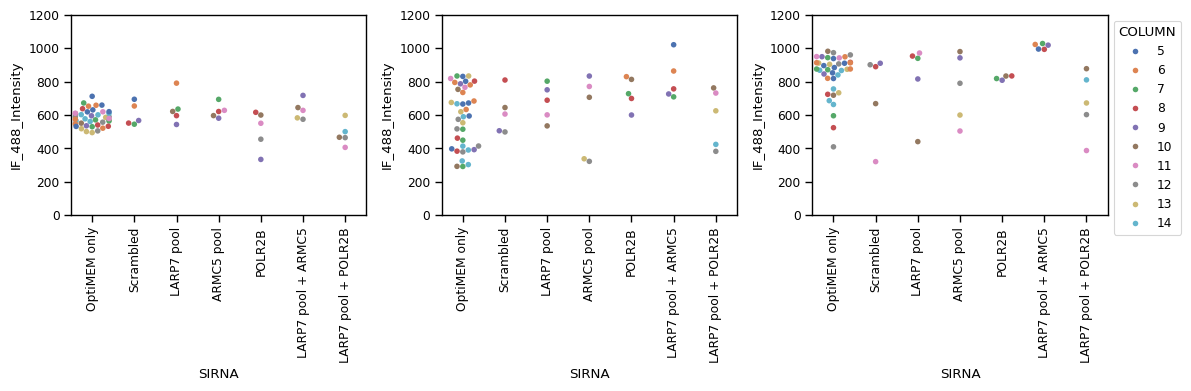

In [28]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 3, figsize = (12,4))

sns.swarmplot(IntensitiesByWell_Experiment1.query('PRIMARY != "No primary"'),
              x = 'SIRNA', order = sirna_order,
              y = 'IF_488_Intensity',
              hue = 'COLUMN', palette = 'deep',
              legend = False,
              s = 4,
              ax = a[0])

sns.swarmplot(IntensitiesByWell_Experiment2.query('PRIMARY != "No primary"'),
              x = 'SIRNA', order = sirna_order,
              y = 'IF_488_Intensity',
              hue = 'COLUMN', palette = 'deep',
              legend = False,
              s = 4,
              ax = a[1])

g = sns.swarmplot(IntensitiesByWell_Experiment3.query('PRIMARY != "No primary"'),
              x = 'SIRNA', order = sirna_order,
              y = 'IF_488_Intensity',
              hue = 'COLUMN', palette = 'deep',
              legend = True,
              s = 4,
              ax = a[2])

sns.move_legend(g, 'upper left', bbox_to_anchor = (1,1))

for i in [0,1,2]:
    a[i].set_ylim(0,1200)
    a[i].tick_params(axis = 'x', rotation = 90)

plt.tight_layout()

/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 5.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 25.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 13.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


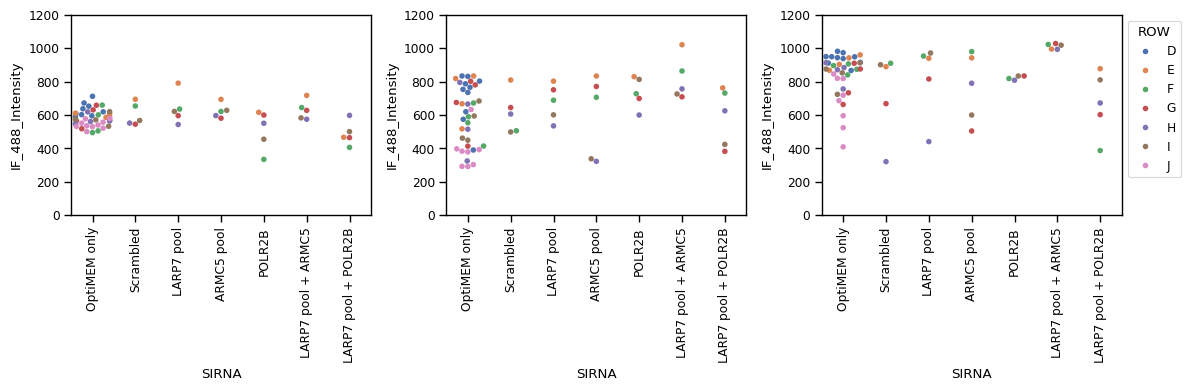

In [29]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 3, figsize = (12,4))

sns.swarmplot(IntensitiesByWell_Experiment1.query('PRIMARY != "No primary"'),
              x = 'SIRNA', order = sirna_order,
              y = 'IF_488_Intensity',
              hue = 'ROW', palette = 'deep',
              legend = False,
              s = 4,
              ax = a[0])

sns.swarmplot(IntensitiesByWell_Experiment2.query('PRIMARY != "No primary"'),
              x = 'SIRNA', order = sirna_order,
              y = 'IF_488_Intensity',
              hue = 'ROW', palette = 'deep',
              legend = False,
              s = 4,
              ax = a[1])

g = sns.swarmplot(IntensitiesByWell_Experiment3.query('PRIMARY != "No primary"'),
              x = 'SIRNA', order = sirna_order,
              y = 'IF_488_Intensity',
              hue = 'ROW', palette = 'deep',
              legend = True,
              s = 4,
              ax = a[2])

sns.move_legend(g, 'upper left', bbox_to_anchor = (1,1))

for i in [0,1,2]:
    a[i].set_ylim(0,1200)
    a[i].tick_params(axis = 'x', rotation = 90)

plt.tight_layout()

In [30]:
IntensitiesByWell_Experiment1.SIRNA.unique()

array(['OptiMEM only', 'Scrambled', 'LARP7 pool', 'ARMC5 pool', 'POLR2B',
       'LARP7 pool + ARMC5', 'LARP7 pool + POLR2B'], dtype=object)

Text(0.5, 1.0, '251117_LARP7_7SK \n OptiMEM only wells')

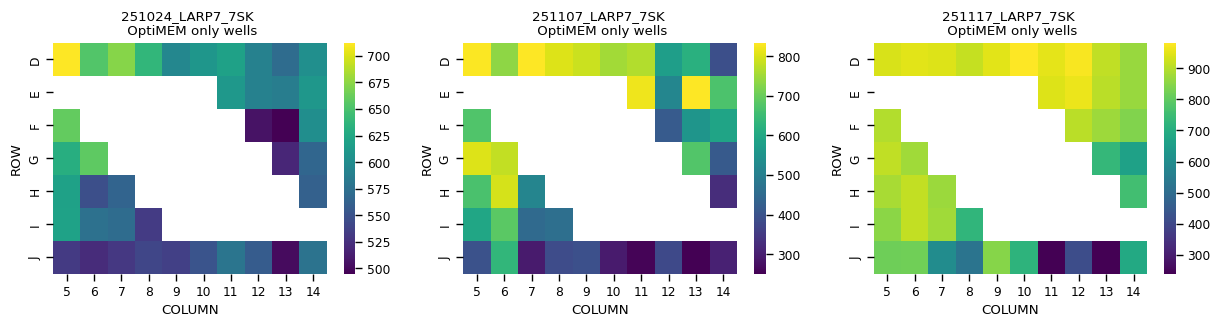

In [31]:
f, a = plt.subplots(ncols = 3, figsize = (15,3))

heat = IntensitiesByWell_Experiment1.query('SIRNA == "OptiMEM only"').pivot(index = 'ROW', columns = 'COLUMN', values = 'IF_488_Intensity')
sns.heatmap(heat, cmap = 'viridis', ax = a[0])

heat = IntensitiesByWell_Experiment2.query('SIRNA == "OptiMEM only"').pivot(index = 'ROW', columns = 'COLUMN', values = 'IF_488_Intensity')
sns.heatmap(heat, cmap = 'viridis', ax = a[1])

heat = IntensitiesByWell_Experiment3.query('SIRNA == "OptiMEM only"').pivot(index = 'ROW', columns = 'COLUMN', values = 'IF_488_Intensity')
sns.heatmap(heat, cmap = 'viridis', ax = a[2])

a[0].set_title('251024_LARP7_7SK \n OptiMEM only wells')
a[1].set_title('251107_LARP7_7SK \n OptiMEM only wells')
a[2].set_title('251117_LARP7_7SK \n OptiMEM only wells')

In [33]:
IntensitiesByWell_Experiment3_Filt = IntensitiesByWell_Experiment3.query('COLUMN not in [11,12,13,14] & ROW not in ["I","J"]')
IntensitiesByWell_Experiment2_Filt = IntensitiesByWell_Experiment2.query('COLUMN not in [11,12,13,14] & ROW not in ["I","J"]')

/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 17.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


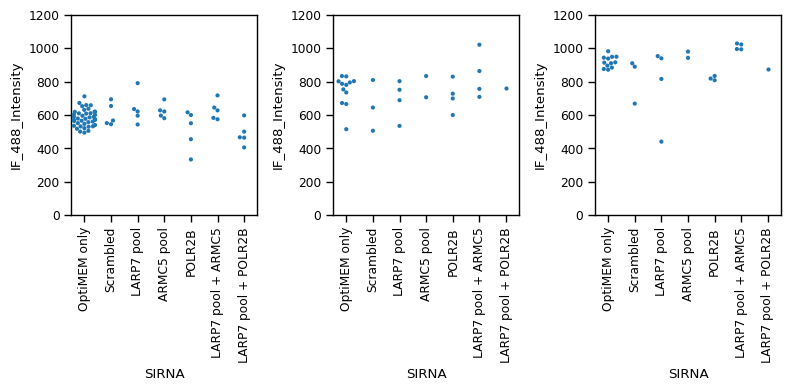

In [34]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 3, figsize = (8,4))

sns.swarmplot(IntensitiesByWell_Experiment1,
              x = 'SIRNA', order = sirna_order,
              y = 'IF_488_Intensity',
              hue = 'PRIMARY',
              legend = False,
              s = 3,
              ax = a[0])

sns.swarmplot(IntensitiesByWell_Experiment2_Filt,
              x = 'SIRNA', order = sirna_order,
              y = 'IF_488_Intensity',
              hue = 'PRIMARY',
              legend = False,
              s = 3,
              ax = a[1])

sns.swarmplot(IntensitiesByWell_Experiment3_Filt,
              x = 'SIRNA', order = sirna_order,
              y = 'IF_488_Intensity',
              hue = 'PRIMARY',
              legend = False,
              s = 3,
              ax = a[2])

for i in [0,1,2]:
    a[i].set_ylim(0,1200)
    a[i].tick_params(axis = 'x', rotation = 90)

plt.tight_layout()

## subtract background signal and plot as fold change from scrambled

In [35]:
Experiment1_FISH647_Zero = IntensitiesByWell_Experiment1.query('FISH == "No probes"')['FISH_647_Intensity'].mean()
Experiment2_FISH647_Zero = IntensitiesByWell_Experiment2.query('FISH == "No probes"')['FISH_647_Intensity'].mean()
Experiment3_FISH647_Zero = IntensitiesByWell_Experiment3.query('FISH == "No probes"')['FISH_647_Intensity'].mean()

IntensitiesByWell_Experiment1['FISH_647_Intensity_BGS'] = IntensitiesByWell_Experiment1['FISH_647_Intensity'] - Experiment1_FISH647_Zero
IntensitiesByWell_Experiment2['FISH_647_Intensity_BGS'] = IntensitiesByWell_Experiment2['FISH_647_Intensity'] - Experiment2_FISH647_Zero
IntensitiesByWell_Experiment2_Filt['FISH_647_Intensity_BGS'] = IntensitiesByWell_Experiment2_Filt['FISH_647_Intensity'] - Experiment2_FISH647_Zero
IntensitiesByWell_Experiment3['FISH_647_Intensity_BGS'] = IntensitiesByWell_Experiment3['FISH_647_Intensity'] - Experiment3_FISH647_Zero
IntensitiesByWell_Experiment3_Filt['FISH_647_Intensity_BGS'] = IntensitiesByWell_Experiment3_Filt['FISH_647_Intensity'] - Experiment3_FISH647_Zero

Experiment1_FISH647_NV = IntensitiesByWell_Experiment1.query('FISH != "No probes" & SIRNA == "Scrambled"')['FISH_647_Intensity_BGS'].mean()
Experiment2_FISH647_NV = IntensitiesByWell_Experiment2.query('FISH != "No probes" & SIRNA == "Scrambled"')['FISH_647_Intensity_BGS'].mean()
Experiment3_FISH647_NV = IntensitiesByWell_Experiment3.query('FISH != "No probes" & SIRNA == "Scrambled"')['FISH_647_Intensity_BGS'].mean()

IntensitiesByWell_Experiment1['FISH_647_Intensity_FC'] = IntensitiesByWell_Experiment1['FISH_647_Intensity_BGS'] / Experiment1_FISH647_NV
IntensitiesByWell_Experiment2_Filt['FISH_647_Intensity_FC'] = IntensitiesByWell_Experiment2_Filt['FISH_647_Intensity_BGS'] / Experiment2_FISH647_NV
IntensitiesByWell_Experiment3_Filt['FISH_647_Intensity_FC'] = IntensitiesByWell_Experiment3_Filt['FISH_647_Intensity_BGS'] / Experiment3_FISH647_NV

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_14001/2681224656.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment2_Filt['FISH_647_Intensity_BGS'] = IntensitiesByWell_Experiment2_Filt['FISH_647_Intensity'] - Experiment2_FISH647_Zero
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_14001/2681224656.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment3_Filt['FISH_647_Intensity_BGS'] = IntensitiesByWell_Experiment3_Filt['FISH_647_I

In [36]:
Experiment1_IF_Zero = 225.89
Experiment2_IF_Zero = IntensitiesByWell_Experiment2.query('PRIMARY == "No primary"')['IF_488_Intensity'].mean()
Experiment3_IF_Zero = IntensitiesByWell_Experiment3.query('PRIMARY == "No primary"')['IF_488_Intensity'].mean()

IntensitiesByWell_Experiment1['IF_488_Intensity_BGS'] = IntensitiesByWell_Experiment1['IF_488_Intensity'] - Experiment1_IF_Zero
IntensitiesByWell_Experiment2['IF_488_Intensity_BGS'] = IntensitiesByWell_Experiment2['IF_488_Intensity'] - Experiment2_IF_Zero
IntensitiesByWell_Experiment2_Filt['IF_488_Intensity_BGS'] = IntensitiesByWell_Experiment2_Filt['IF_488_Intensity'] - Experiment2_IF_Zero
IntensitiesByWell_Experiment3['IF_488_Intensity_BGS'] = IntensitiesByWell_Experiment3['IF_488_Intensity'] - Experiment2_IF_Zero
IntensitiesByWell_Experiment3_Filt['IF_488_Intensity_BGS'] = IntensitiesByWell_Experiment3_Filt['IF_488_Intensity'] - Experiment3_IF_Zero

Experiment1_IF488_NV = IntensitiesByWell_Experiment1.query('FISH != "No probes" & SIRNA == "Scrambled"')['IF_488_Intensity_BGS'].mean()
Experiment2_IF488_NV = IntensitiesByWell_Experiment2_Filt.query('FISH != "No probes" & SIRNA == "Scrambled"')['IF_488_Intensity_BGS'].mean()
Experiment3_IF488_NV = IntensitiesByWell_Experiment3_Filt.query('FISH != "No probes" & SIRNA == "Scrambled"')['IF_488_Intensity_BGS'].mean()

IntensitiesByWell_Experiment1['IF_488_Intensity_FC'] = IntensitiesByWell_Experiment1['IF_488_Intensity_BGS'] / Experiment1_IF488_NV 
IntensitiesByWell_Experiment2_Filt['IF_488_Intensity_FC'] = IntensitiesByWell_Experiment2_Filt['IF_488_Intensity_BGS'] / Experiment2_IF488_NV 
IntensitiesByWell_Experiment3_Filt['IF_488_Intensity_FC'] = IntensitiesByWell_Experiment3_Filt['IF_488_Intensity_BGS'] / Experiment2_IF488_NV 

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_14001/2185609621.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment2_Filt['IF_488_Intensity_BGS'] = IntensitiesByWell_Experiment2_Filt['IF_488_Intensity'] - Experiment2_IF_Zero
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_14001/2185609621.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment3_Filt['IF_488_Intensity_BGS'] = IntensitiesByWell_Experiment3_Filt['IF_488_Intensity'] - 

In [37]:
AllWells = pd.concat([IntensitiesByWell_Experiment1, IntensitiesByWell_Experiment2_Filt, IntensitiesByWell_Experiment3_Filt])
TransfectedOnly = AllWells.query('SIRNA != "OptiMEM only"')

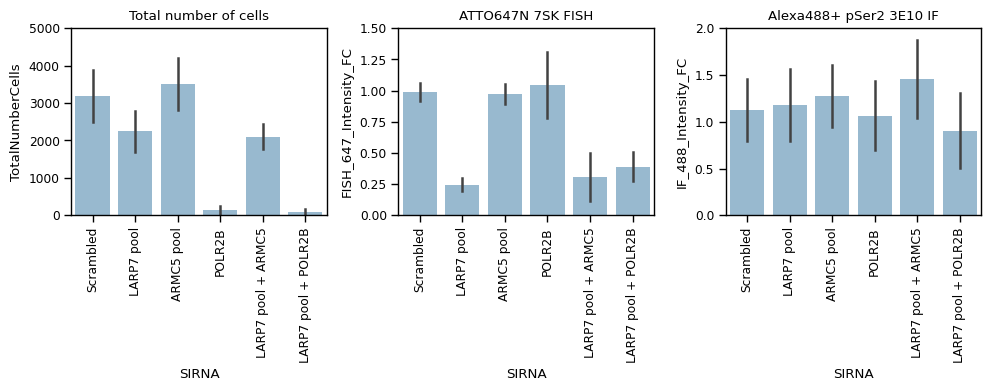

In [38]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 3, figsize = (10,4))

sns.barplot(TransfectedOnly,
              x = 'SIRNA',
              y = 'TotalNumberCells',
            errorbar = 'sd',
            alpha = 0.5,
              ax = a[0])

sns.barplot(TransfectedOnly,
              x = 'SIRNA',
              y = 'FISH_647_Intensity_FC',
            errorbar = 'sd',
            alpha = 0.5,
              ax = a[1])

sns.barplot(TransfectedOnly,
              x = 'SIRNA',
              y = 'IF_488_Intensity_FC',
            errorbar = 'sd',
            alpha = 0.5,
              ax = a[2])

a[0].tick_params(axis = 'x', rotation = 90)
a[1].tick_params(axis = 'x', rotation = 90)
a[2].tick_params(axis = 'x', rotation = 90)

a[0].set_ylim(0, 5000)
a[1].set_ylim(0, 1.5)
a[2].set_ylim(0, 2)

a[0].set_title('Total number of cells')
a[1].set_title('ATTO647N 7SK FISH')
a[2].set_title('Alexa488+ pSer2 3E10 IF')

plt.tight_layout()

In [39]:
sns.color_palette('deep')

[(0.2980392156862745, 0.4470588235294118, 0.6901960784313725),
 (0.8666666666666667, 0.5176470588235295, 0.3215686274509804),
 (0.3333333333333333, 0.6588235294117647, 0.40784313725490196),
 (0.7686274509803922, 0.3058823529411765, 0.3215686274509804),
 (0.5058823529411764, 0.4470588235294118, 0.7019607843137254),
 (0.5764705882352941, 0.47058823529411764, 0.3764705882352941),
 (0.8549019607843137, 0.5450980392156862, 0.7647058823529411),
 (0.5490196078431373, 0.5490196078431373, 0.5490196078431373),
 (0.8, 0.7254901960784313, 0.4549019607843137),
 (0.39215686274509803, 0.7098039215686275, 0.803921568627451)]

In [40]:
pal = sns.color_palette(['grey',
                         sns.color_palette('deep')[2],
                         sns.color_palette('pastel')[5],
                         sns.color_palette('pastel')[1],
                         sns.color_palette('deep')[9],
                         sns.color_palette('pastel')[3]])

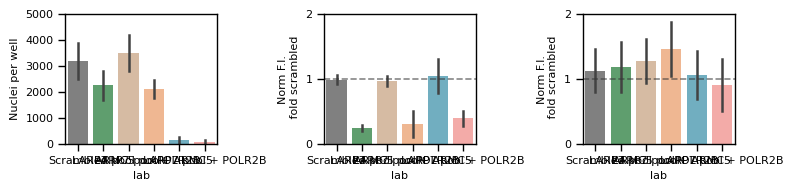

In [41]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 3, figsize = (8,2))

sns.barplot(TransfectedOnly,
              x = 'SIRNA', order  =['Scrambled',
                                    'LARP7 pool',
                                    'ARMC5 pool',
                                    'LARP7 pool + ARMC5',
                                    'POLR2B',
                                    'LARP7 pool + POLR2B'],
              y = 'TotalNumberCells',
            errorbar = 'sd',
            palette = pal,
              ax = a[0])

sns.barplot(TransfectedOnly,
              x = 'SIRNA',  order  =['Scrambled',
                                    'LARP7 pool',
                                    'ARMC5 pool',
                                    'LARP7 pool + ARMC5',
                                    'POLR2B',
                                    'LARP7 pool + POLR2B'],
              y = 'FISH_647_Intensity_FC',
            errorbar = 'sd',
            palette = pal,
              ax = a[1])

sns.barplot(TransfectedOnly,
              x = 'SIRNA',  order  =['Scrambled',
                                    'LARP7 pool',
                                    'ARMC5 pool',
                                    'LARP7 pool + ARMC5',
                                    'POLR2B',
                                    'LARP7 pool + POLR2B'],
              y = 'IF_488_Intensity_FC',
            errorbar = 'sd',
            palette = pal,
              ax = a[2])

a[0].tick_params(axis = 'both', labelsize = 8)
a[1].tick_params(axis = 'both', labelsize = 8)
a[2].tick_params(axis = 'both', labelsize = 8)

a[0].set_ylim(0, 5000)
a[1].set_ylim(0, 2)
a[1].set_yticks([0,1,2])
a[2].set_ylim(0, 2)
a[2].set_yticks([0,1,2])

a[0].set_ylabel('Nuclei per well',fontsize = 8)
a[1].set_ylabel('Norm F.I.\n fold scrambled',fontsize = 8)
a[2].set_ylabel('Norm F.I.\n fold scrambled',fontsize = 8)

a[0].set_xlabel('lab',fontsize = 8)
a[1].set_xlabel('lab',fontsize = 8)
a[2].set_xlabel('lab',fontsize = 8)



a[1].axhline(1, linestyle = '--', color = 'xkcd:dark grey', alpha = 0.6)
a[2].axhline(1, linestyle = '--', color = 'xkcd:dark grey', alpha = 0.6)


plt.tight_layout()

plt.savefig('larp7_7sk.svg')

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_14001/563879705.py:5: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  sns.barplot(TransfectedOnly.reset_index(),


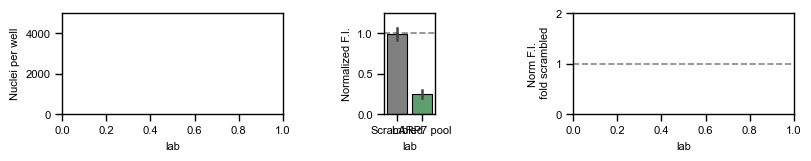

In [50]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 3, figsize = (8,1.5), layout = 'constrained')

sns.barplot(TransfectedOnly.reset_index(),
              x = 'SIRNA',  order  =['Scrambled',
                                    'LARP7 pool'],
              y = 'FISH_647_Intensity_FC',
            edgecolor = 'black',
            errorbar = 'sd',
            palette = pal,
              ax = a[1])

a[0].tick_params(axis = 'both', labelsize = 8)
a[1].tick_params(axis = 'both', labelsize = 8)
a[2].tick_params(axis = 'both', labelsize = 8)

a[0].set_ylim(0, 5000)
a[1].set_ylim(0, 2)
a[1].set_yticks([0,1,2])
a[2].set_ylim(0, 2)
a[2].set_yticks([0,1,2])

a[0].set_ylabel('Nuclei per well',fontsize = 8)
a[1].set_ylabel('Normalized F.I.',fontsize = 8)
a[2].set_ylabel('Norm F.I.\n fold scrambled',fontsize = 8)

a[0].set_xlabel('lab',fontsize = 8)
a[1].set_xlabel('lab',fontsize = 8)
a[2].set_xlabel('lab',fontsize = 8)

a[1].set_box_aspect(2)
a[1].set_ylim(0, 1.25)
a[1].set_yticks([0,0.5,1])


a[1].axhline(1, linestyle = '--', color = 'xkcd:dark grey', alpha = 0.6)
a[2].axhline(1, linestyle = '--', color = 'xkcd:dark grey', alpha = 0.6)

plt.savefig('larp7_7sk_fishonly.svg')